# Load data for GNN PROTAC splitter - Node classifier - Experimental Architectures

# ToDo

1. Make test set from AZ data. Make AZ data which is in public and AZ data which is not in public.

1.5 Make test set based on "cluster-leave-one-out"

1.75 5-fold cross validation - Check if it is overfitting or not

1.8 Other methods to see if the GNN overfits or not

2. Fix points of improvement for BoundaryNode GNN. Notes down below.

2.5 Make a dataframe for all evaluation metrics. Export to CSV and analyze it in Excel.
    * Is it correct to say that some protacs have "no" linker? Some have their length of their linker equal to zero.
        IF it is incorrect, then the dataprocessing may need revisions.

3. Clean up code.



1. Generate a complete dataset of PROTACs of all combinations between POI, Linker, E3
    1.1 Use a smaller subset of these rather than generating new ones.

2. Save the set of smiles for the anonymous MS for each substructure. Use these when generating the test set.

3. Make the nameing from Stefanos and Evas code congruent. Standardize mine and theirs.

4. Have the PROTACdataset class call on the same function as prepare_data. So If I update the function, it automatically applies to both. To prevent mismatch / outdated functions.

5. Retry adding rings to linker an applying MS

6. Make the subset selection of the complete set of random PROTACs to be random but reproducible with a seed.

7. Improve where the model is allowed to choose as the "boundary". The linker "leaks" into the E3 and POI and can define them as linker - this happens because POI-L boundary is placed within a ring, and the "first" linker atom is still within the same ring.
    See other "points of improvement" as well



In [1]:
# Standard library imports
import os
import sys
import io

# Data handling and scientific computing
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.linalg import inv

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
from torch_geometric.nn import GCNConv, NNConv
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

# RDKit for cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, GetPeriodicTable
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdchem
from rdkit.Chem import rdmolops
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import rdMolHash


# NetworkX for network analysis
import networkx as nx

# Matplotlib for plotting and visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Other utilities
from tqdm import tqdm
from PIL import Image

# External datasets
from datasets import load_dataset


import re
import random


from IPython.display import display

sys.path.append('./Code/TestingGround/src/models/')

/home/knkn308/.conda/envs/env-protac-toolkit/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from all_functions import *

# User inputs:
Note that new datasets (as in a new "dataname") have all descriptors calculated from scratch, which is then saved. If there exists a dataset with a given dataname, it is retrived instead.

In [3]:
Highlighted_graph_descriptors = ['betweenness', 'local_betweenness_5', 'local_eigenvectors_x', 'local_normAvgShortestPath_5', 'local_prod_betweenness_avgShortestPath_4']   ##Which graph descriptors to calculate for the data and use to train the GNN model. There exists more graph descriptors
Existing_datanames =  ['NoGraphDesc','NoGraphDesc_20K']
Existing_models = ["model_GraphDescriptors-b-lb-le-lasp-lpbasp_FullAibeDataset.pth", "model_NoGraphDescriptors_FullAibeDataset.pth", "GraphConv_2_3layers_AIBE_GraphDescriptors-b-lb-le-lasp-lpbasp_Set1RDKitfeatures"]

#user input
graph_descriptor_list = [] #Highlighted_graph_descriptors
dataname = "NoGraphDesc_2K"  #Existing_datanames[0] # Which dataset to use

load_testsets = False
training_epochs = 5
save_model = True
model_name = "GraphConv_B_size2_rand20Ktrain" #f"GraphConv_3_BoundaryNodeSplitter_3layers_{dataname}.pth" #f"GraphConv_2_3layers_{dataname}" #either False or str. For loading existing models OR saving trained model

# Load data
Training, validation, test

In [4]:
test_set_names_core = ['test_set_1_non_public_poi_v1', 'test_set_2_non_public_e3_v1', 'test_set_3__non_public_linker_v1', 'test_set_4_non_public_protac', 'test_set_5_public_protac_v1', 'test_set_1_2_non_public_poi_and_linker', 'test_set_2_2_non_public_e3_and_linker']
test_set_names = [s + dataname for s in test_set_names_core]

In [5]:
current_directory = os.getcwd()
raw_data_path = os.path.join(current_directory, "..", "..", "data","processed")

In [6]:
raw_data_path

'/projects/cc/kallberg_knkn308/Code/PROTAC-Splitter/notebooks/GNN/../../data/processed'

In [7]:
training_dataset = load_PROTACdataset(name=f'{dataname}_train_rand', raw_data_path=raw_data_path)


In [8]:
training_dataset = load_PROTACdataset(name=f'{dataname}_train_rand', raw_data_path=raw_data_path)
validation_dataset = load_PROTACdataset(name=f'{dataname}_val_rand', raw_data_path=raw_data_path)

if load_testsets:
    if isinstance(load_testsets,list):
        for i in load_testsets:
            if i == 0:
                test_dataset_1 = load_PROTACdataset(name=test_set_names[0], raw_data_path=raw_data_path)
            if i == 1:
                test_dataset_2 = load_PROTACdataset(name=test_set_names[1], raw_data_path=raw_data_path)
            if i == 2:
                test_dataset_3 = load_PROTACdataset(name=test_set_names[2], raw_data_path=raw_data_path)
            if i == 3:
                test_dataset_4 = load_PROTACdataset(name=test_set_names[3], raw_data_path=raw_data_path)
            if i == 4:
                test_dataset_5 = load_PROTACdataset(name=test_set_names[4], raw_data_path=raw_data_path)
            if i == 5:
                test_dataset_1_2 = load_PROTACdataset(name=test_set_names[5], raw_data_path=raw_data_path)
            if i == 6:
                test_dataset_2_2 = load_PROTACdataset(name=test_set_names[6], raw_data_path=raw_data_path)
    else:
        test_dataset_1 = load_PROTACdataset(name=test_set_names[0], raw_data_path=raw_data_path)
        test_dataset_2 = load_PROTACdataset(name=test_set_names[1], raw_data_path=raw_data_path)
        test_dataset_3 = load_PROTACdataset(name=test_set_names[2], raw_data_path=raw_data_path)
        test_dataset_4 = load_PROTACdataset(name=test_set_names[3], raw_data_path=raw_data_path)
        test_dataset_5 = load_PROTACdataset(name=test_set_names[4], raw_data_path=raw_data_path)
        test_dataset_1_2 = load_PROTACdataset(name=test_set_names[5], raw_data_path=raw_data_path)
        test_dataset_2_2 = load_PROTACdataset(name=test_set_names[6], raw_data_path=raw_data_path)



# Model

## Model functions

In [9]:

def val_test_split(validation_dataset, relative_test_size=0.3):

    val_size = len(validation_dataset)
    test_size = int(relative_test_size * val_size)
    val_size_new = val_size - test_size
    val_dataset_subset, test_dataset_subset  = random_split(validation_dataset, [val_size_new, test_size], generator=torch.Generator().manual_seed(42))
    
    val_dataset = [val_dataset_subset[i] for i in range(val_size_new)]
    test_dataset = [test_dataset_subset[i] for i in range(test_size)]
    return val_dataset, test_dataset

## GNN

### Node Classifier

In [10]:
"""

from torch_geometric.nn import GraphConv

#GCNConv worked well before, with a test accuracy of around 0.93
#GraphConv: maybe converges faster?

class NodeClassifierGNN(torch.nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim):
        super(NodeClassifierGNN, self).__init__()
        self.conv1 = GraphConv(node_feature_dim, 64)# edge_dim=edge_feature_dim)
        self.conv2 = GraphConv(64, 32)# edge_dim=edge_feature_dim)
        self.conv3 = GraphConv(32, 64)
        self.out = torch.nn.Linear(64, 3)  # Output layer for 3 classes
        
    def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        y = self.out(z)

        return y

# Training function
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        
        optimizer.zero_grad()
        
        out = model(node_attr=data.x, edge_index=data.edge_index)#, edge_attr=data.edge_attr)
        # Convert one-hot encoded vectors to class indices
        target = data.node_substructure_label.argmax(dim=1)


        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)# , edge_attr=data.edge_attr)
            pred = out.argmax(dim=1)

            # Convert one-hot encoded vectors to class indices for comparison
            target = data.node_substructure_label.argmax(dim=1)
            
            correct += pred.eq(target).sum().item()
            total += data.node_substructure_label.size(0)
    return correct / total

def predict(model, data):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        out = model(data.x, data.edge_index) #, edge_attr=data.edge_attr)
        probabilities = F.softmax(out, dim=1)
        class_predictions = probabilities.argmax(dim=1)
    return class_predictions, probabilities

train_dataset = training_dataset
val_dataset = validation_dataset #, test_dataset = val_test_split(validation_dataset, relative_test_size=0.3)  #val_dataset_old, test_dataset_old = train_test_split(validation_dataset, test_size=0.3, random_state=42) 


# Create DataLoaders for batch processing (adjust batch_size as needed)
batch_size = 1                                                   #Larger batchsize gave worse result. Try again. Because of edge indexes?
torch.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
#test_loader = DataLoader(test_dataset, batch_size=batch_size)


# Model instantiation
if model_name and os.path.isfile(model_name):
    model = torch.load(model_name)
else:
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features 
    model = NodeClassifierGNN(node_feature_dim, edge_feature_dim)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss() # Note: CrossEntropyLoss in PyTorch expects raw scores (logits) and class indices, not one-hot encoded labels If your labels are one-hot encoded, you might need to convert them to class indices


# Training and evaluation loop
for epoch in range(training_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_accuracy = evaluate(model, val_loader)
    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1}: Loss: {train_loss}, Val Accuracy: {val_accuracy}')

# Test evaluation
#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')"""

"\n\nfrom torch_geometric.nn import GraphConv\n\n#GCNConv worked well before, with a test accuracy of around 0.93\n#GraphConv: maybe converges faster?\n\nclass NodeClassifierGNN(torch.nn.Module):\n    def __init__(self, node_feature_dim, edge_feature_dim):\n        super(NodeClassifierGNN, self).__init__()\n        self.conv1 = GraphConv(node_feature_dim, 64)# edge_dim=edge_feature_dim)\n        self.conv2 = GraphConv(64, 32)# edge_dim=edge_feature_dim)\n        self.conv3 = GraphConv(32, 64)\n        self.out = torch.nn.Linear(64, 3)  # Output layer for 3 classes\n        \n    def forward(self, node_attr, edge_index): #, edge_attr):\n        # First Graph Convolution Layer\n        z = self.conv1(node_attr, edge_index)#, edge_attr)\n        z = F.relu(z)\n\n        # Second Graph Convolution Layer\n        z = self.conv2(z, edge_index)#, edge_attr)\n        z = F.relu(z)\n\n        # Third Graph Convolution Layer\n        z = self.conv3(z, edge_index)#, edge_attr)\n        z = F.relu

### Boundary node classifier

#### Points of improvement:

If the POI (or E3) is smaller than 9 atoms, then subtract the max_val from that node in out, and recalculate pred_boundary_nodes => Ensure that ligands are not too small.

If the removal of the POI (or E3) boundary node does not increase the number of disconected subgraphs by 1, then -||-

If the final substructures results in a ring breakage, e.g POI and Linker shares nodes in a ring, then -||-

In [ ]:
#Further criteria for legal nodes: The the POI-L node and Linker nodes can't be a part of the same ring => Calculate the resulting nodes for the linker, POI and E3. ...
# ... See if any ring has nodes from two classes. If a ring has nodes from Linker and E3, then the E3-L choice was poor. If the ring has nodes from Linker and POI, the POI-L choice was poor.
#def will_boundary_nodes_split_rings(mol, poi_L_idx, e3_l_idx):
#    ring_info = mol.GetRingInfo()
#    ring_idx = []
#    for atom in mol.GetAtoms():
#        if ring_info.IsAtomInRing(atom.GetIdx()) and (atom.GetIdx() != poi_L_idx) and (atom.GetIdx() != e3_l_idx):
#            ring_idx.append(atom.GetIdx())

In [27]:
#Duplicated and modified: Altered prediction.    



train_dataset = training_dataset
val_dataset = validation_dataset #, test_dataset = val_test_split(validation_dataset, relative_test_size=0.3)  #val_dataset_old, test_dataset_old = train_test_split(validation_dataset, test_size=0.3, random_state=42) 


# Create DataLoaders for batch processing (adjust batch_size as needed)
batch_size = 128                                                #Larger batchsize gave worse result. Try again. Because of edge indexes?
torch.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)


if load_testsets:
    torch.manual_seed(42)
    test1_loader = DataLoader(test_dataset_1, batch_size=batch_size, shuffle=True)
    torch.manual_seed(42)
    test2_loader = DataLoader(test_dataset_2, batch_size=batch_size, shuffle=True)
    torch.manual_seed(42)
    test3_loader = DataLoader(test_dataset_3, batch_size=batch_size, shuffle=True)
    torch.manual_seed(42)
    test4_loader = DataLoader(test_dataset_4, batch_size=batch_size, shuffle=True)
    torch.manual_seed(42)
    test5_loader = DataLoader(test_dataset_5, batch_size=batch_size, shuffle=True)
    torch.manual_seed(42)
    test1_2_loader = DataLoader(test_dataset_1_2, batch_size=batch_size, shuffle=True)
    torch.manual_seed(42)
    test2_2_loader = DataLoader(test_dataset_2_2, batch_size=batch_size, shuffle=True)

#test_loader = DataLoader(test_dataset, batch_size=batch_size)


# Model instantiation
if model_name and os.path.isfile(model_name):
    model = torch.load(model_name)
else:
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features 
    model = NodeClassifierGNN(node_feature_dim, edge_feature_dim)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss() # Note: CrossEntropyLoss in PyTorch expects raw scores (logits) and class indices, not one-hot encoded labels If your labels are one-hot encoded, you might need to convert them to class indices


# Training and evaluation loop
import matplotlib.pyplot as plt

# Replace the following list with your accuracy values
loss_list = []
accuracy_values = [[], [], [], [], [], [], [], [], []]
for epoch in range(training_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, epoch)
    val_accuracy = evaluate(model, val_loader, epoch)
    train_accuracy = evaluate(model, train_loader, epoch)
    accuracy_values[0].append(val_accuracy)
    accuracy_values[8].append(train_accuracy)
    loss_list.append(train_loss)
    if load_testsets:
        test1_accuracy = evaluate(model, test1_loader, epoch)
        test2_accuracy = evaluate(model, test2_loader, epoch)
        test3_accuracy = evaluate(model, test3_loader, epoch)
        test4_accuracy = evaluate(model, test4_loader, epoch)
        test5_accuracy = evaluate(model, test5_loader, epoch)
        test1_2_accuracy = evaluate(model, test1_2_loader, epoch)
        test2_2_accuracy = evaluate(model, test2_2_loader, epoch)
        accuracy_values[1].append(test1_accuracy)
        accuracy_values[2].append(test2_accuracy)
        accuracy_values[3].append(test3_accuracy)
        accuracy_values[4].append(test4_accuracy)
        accuracy_values[5].append(test5_accuracy)
        accuracy_values[6].append(test1_2_accuracy)
        accuracy_values[7].append(test2_2_accuracy)


    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1}: Loss: {train_loss}')
        print(f'Val Accuracy: {val_accuracy}')
        print(f'Train Accuracy: {train_accuracy}')
        if load_testsets:
            print(f'{test_set_names[0]} Accuracy: {test1_accuracy}')
            print(f'{test_set_names[1]} Accuracy: {test2_accuracy}')
            print(f'{test_set_names[2]} Accuracy: {test3_accuracy}')
            print(f'{test_set_names[3]} Accuracy: {test4_accuracy}')
            print(f'{test_set_names[4]} Accuracy: {test5_accuracy}')
            print(f'{test_set_names[5]} Accuracy: {test1_2_accuracy}')
            print(f'{test_set_names[6]} Accuracy: {test2_2_accuracy}')
        





# Test evaluation
#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')

Epoch 1: Loss: 0.20758112626416342
Val Accuracy: 0.26878101402373245
Train Accuracy: 0.2736149875740776
Epoch 2: Loss: 0.1622826595391546
Val Accuracy: 0.25104638619201725
Train Accuracy: 0.2401299942649589
Epoch 3: Loss: 0.1478247195482254
Val Accuracy: 0.38040992448759436
Train Accuracy: 0.38271840948193464
Epoch 4: Loss: 0.13652670596327102
Val Accuracy: 0.4773678532901834
Train Accuracy: 0.48532211814184667
Epoch 5: Loss: 0.1256140773849828
Val Accuracy: 0.5184466019417475
Train Accuracy: 0.529099598547123


In [ ]:
"""
Epoch 1: Loss: 0.20758112626416342
Val Accuracy: 0.26878101402373245
Train Accuracy: 0.2736149875740776
Epoch 2: Loss: 0.1622826595391546
Val Accuracy: 0.25104638619201725
Train Accuracy: 0.2401299942649589
Epoch 3: Loss: 0.1478247195482254
Val Accuracy: 0.38040992448759436
Train Accuracy: 0.38271840948193464
Epoch 4: Loss: 0.13652670596327102
Val Accuracy: 0.4773678532901834
Train Accuracy: 0.48532211814184667
Epoch 5: Loss: 0.1256140773849828
Val Accuracy: 0.5184466019417475
Train Accuracy: 0.529099598547123






Epoch 1: Loss: 0.13436388688490672
Val Accuracy: 0.4883720930232558
Train Accuracy: 0.488297263431462
Epoch 2: Loss: 0.09438268488820861
Val Accuracy: 0.336254772648386
Train Accuracy: 0.36738703339882123
Epoch 3: Loss: 0.08213974393685075
Val Accuracy: 0.3177716070808747
Train Accuracy: 0.34548210943180235
Epoch 4: Loss: 0.07331708406919943
Val Accuracy: 0.371051718153419
Train Accuracy: 0.37458038766765156
Epoch 5: Loss: 0.06936244510552463
Val Accuracy: 0.3915307185005207
Train Accuracy: 0.39513945825534086
Epoch 6: Loss: 0.06402509141603814
Val Accuracy: 0.41686914265879904
Train Accuracy: 0.407051034141361
Epoch 7: Loss: 0.05983922052690212
Val Accuracy: 0.3915307185005207
Train Accuracy: 0.4086753399440001
Epoch 8: Loss: 0.05557451170211768
Val Accuracy: 0.3834606039569594
Train Accuracy: 0.4221184041582229
Epoch 9: Loss: 0.0522610365602133
Val Accuracy: 0.38727872266574104
Train Accuracy: 0.40760793898798015
Epoch 10: Loss: 0.050175765208516486
Val Accuracy: 0.7522561610551892
Train Accuracy: 0.7458193462555884
"""

In [12]:
#extra training
extra_epochs = 0

for i in range(epoch+1,epoch+1+extra_epochs):
    torch.manual_seed(42)
    train_loss = train(model, train_loader, optimizer, criterion, epoch)
    val_accuracy = evaluate(model, val_loader, epoch)
    accuracy_values[0].append(val_accuracy)
    accuracy_values[8].append(train_accuracy)
    loss_list.append(train_loss)
    if load_testsets:
        accuracy_values[1].append(test1_accuracy)
        accuracy_values[2].append(test2_accuracy)
        accuracy_values[3].append(test3_accuracy)
        accuracy_values[4].append(test4_accuracy)
        accuracy_values[5].append(test5_accuracy)
        accuracy_values[6].append(test1_2_accuracy)
        accuracy_values[7].append(test2_2_accuracy)
    
    if (i+1) % 1 == 0:
        print(f'Epoch {i+1}: Loss: {train_loss}, Val Accuracy: {val_accuracy}')

epoch = epoch + 1 + extra_epochs

#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')

AZ Anon Murcko Scaffold substructure match Public
['test_set_1_non_public_poi_v1', 'test_set_2_non_public_e3_v1', 'test_set_3__non_public_linker_v1', 'test_set_4_non_public_protac', 'test_set_5_public_protac_v1', 'test_set_1_2_non_public_poi_and_linker', 'test_set_2_2_non_public_e3_and_linker']


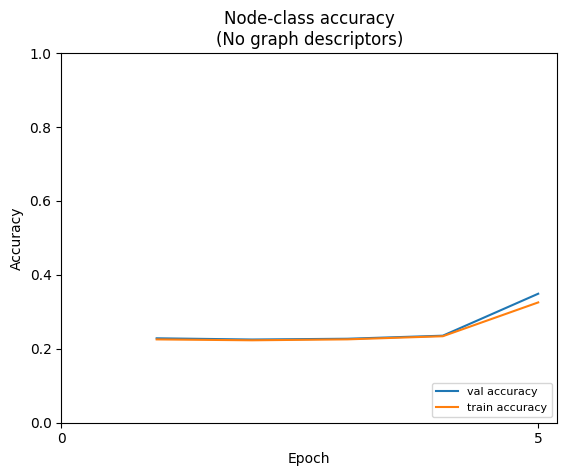

In [13]:

# Create a list of epoch numbers
epochs = list(range(1, len(accuracy_values[0]) + 1))



# Plot the accuracy values against the epoch numbers
plt.plot(epochs, accuracy_values[0], label=f'val accuracy')
plt.plot(epochs, accuracy_values[8], label=f'train accuracy')
if load_testsets:
    plt.plot(epochs, accuracy_values[5], label=f'Pub: POI, Linker, E3')
    plt.plot(epochs, accuracy_values[1], label=f'Pub:      Linker, E3  NoPub: POI')
    plt.plot(epochs, accuracy_values[3], label=f'Pub: POI,         E3  NoPub: Linker')
    plt.plot(epochs, accuracy_values[2], label=f'Pub: POI, Linker,     NoPub: E3')
    plt.plot(epochs, accuracy_values[6], label=f'Pub:              E3  NoPub: POI, Linker')
    plt.plot(epochs, accuracy_values[7], label=f'Pub: POI              NoPub: Linker, E3')
    plt.plot(epochs, accuracy_values[4], label=f'Pub:                  NoPub: POI, Linker, E3')
    print(test_set_names_core)



# Add labels and title to the plot
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Node-class accuracy\n(No graph descriptors)')

# Set the x-axis to only show whole numbers
plt.xticks(range(0, len(epochs)+1,5))

# Set the y-axis limits to span from 0 to 1
plt.ylim(0, 1)

# Move the legend to the bottom right corner
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), prop={'size': 8})

# Display the plot
print("AZ Anon Murcko Scaffold substructure match Public")

plt.show()



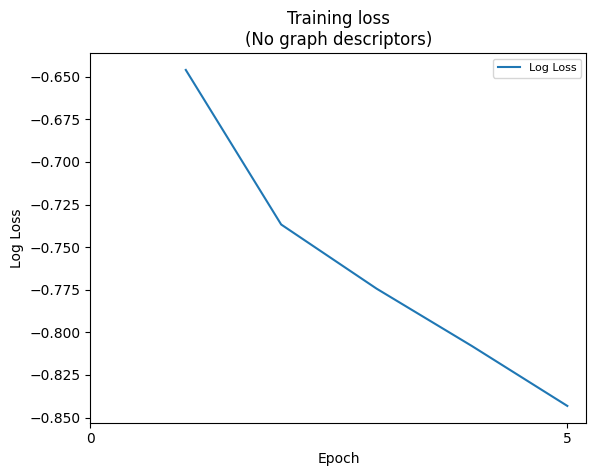

In [14]:
# Create a list of epoch numbers
epochs = list(range(1, len(accuracy_values[0]) + 1))

from math import log

log_loss_list = [log(loss,10) for loss in loss_list]

# Plot the accuracy values against the epoch numbers
plt.plot(epochs, log_loss_list, label=f'Log Loss')




# Add labels and title to the plot
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Training loss\n(No graph descriptors)')

# Set the x-axis to only show whole numbers
plt.xticks(range(0, len(epochs)+1,5))

# Set the y-axis limits to span from 0 to 1
#plt.ylim(0, 1)

# Move the legend to the bottom right corner
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), prop={'size': 8})

# Display the plot
plt.show()

In [15]:
""" No graph descriptors, without recursive predictions of labels
Epoch 1: Loss: 0.6609857269242162, Val Accuracy: 0.7684370918589465
Epoch 2: Loss: 0.47540812419289774, Val Accuracy: 0.8353069220722682
Epoch 3: Loss: 0.40508898413266803, Val Accuracy: 0.8539399216369177
Epoch 4: Loss: 0.36945939222554286, Val Accuracy: 0.8606007836308228
Epoch 5: Loss: 0.3453694614683548, Val Accuracy: 0.8736177622986504
Epoch 6: Loss: 0.3286879391923465, Val Accuracy: 0.8776229865041358
Epoch 7: Loss: 0.31486161196187057, Val Accuracy: 0.878014801915542
Epoch 8: Loss: 0.30634961472926, Val Accuracy: 0.8925990422289943
Epoch 9: Loss: 0.2917316204033629, Val Accuracy: 0.8564214192424902
Epoch 10: Loss: 0.28528244770895383, Val Accuracy: 0.8981279930343927
Epoch 11: Loss: 0.2766986971777034, Val Accuracy: 0.9029603831084022
Epoch 12: Loss: 0.27348323582157574, Val Accuracy: 0.8921636917718764
Epoch 13: Loss: 0.26387562495121947, Val Accuracy: 0.891162385720505
Epoch 14: Loss: 0.26085822126838315, Val Accuracy: 0.8983021332172398
Epoch 15: Loss: 0.25499014398515674, Val Accuracy: 0.8969525468001741

 No graph descriptors, more RDKit descriptors
Epoch 1: Loss: 0.5915545519247977, Val Accuracy: 0.8105790161079669
Epoch 2: Loss: 0.38348508839459855, Val Accuracy: 0.8838484980409229
Epoch 3: Loss: 0.322334529936334, Val Accuracy: 0.8979973878972572
Epoch 4: Loss: 0.2912615137683645, Val Accuracy: 0.9027427078798432
Epoch 5: Loss: 0.27202009187522724, Val Accuracy: 0.895690030474532
Epoch 6: Loss: 0.2547126731535043, Val Accuracy: 0.91162385720505
Epoch 7: Loss: 0.24650338613886202, Val Accuracy: 0.9126686983021333
Epoch 8: Loss: 0.23542749444709815, Val Accuracy: 0.8952982150631258
Epoch 9: Loss: 0.22525550769082184, Val Accuracy: 0.9118415324336091
Epoch 10: Loss: 0.2172198552368565, Val Accuracy: 0.9200261210274271
Epoch 11: Loss: 0.21033756338349988, Val Accuracy: 0.9272094035698738
Epoch 12: Loss: 0.20665528589498272, Val Accuracy: 0.928036569438398
Epoch 13: Loss: 0.19682833343194645, Val Accuracy: 0.9304745319982586
Epoch 14: Loss: 0.19294776737084357, Val Accuracy: 0.9302133217239879
Epoch 15: Loss: 0.1894932356739386, Val Accuracy: 0.9198955158902917


No graph descriptors, WITH recursive predictions of labels               (Built into GNN. Tried also applying same structure to training function, but gave acc around 65)
Epoch 1: Loss: 0.6684036113199641, Val Accuracy: 0.8009577710056596
Epoch 2: Loss: 0.4794131662096075, Val Accuracy: 0.8549847627340009
Epoch 3: Loss: 0.40269028649619615, Val Accuracy: 0.8350021767522856
Epoch 4: Loss: 0.3656960101721839, Val Accuracy: 0.864867218110579
Epoch 5: Loss: 0.34412561228519173, Val Accuracy: 0.8925119721375707
Epoch 6: Loss: 0.31920113086018487, Val Accuracy: 0.8900304745319982
Epoch 7: Loss: 0.30664670950468487, Val Accuracy: 0.8470613844144537
Epoch 8: Loss: 0.3023727468960496, Val Accuracy: 0.885111014366565
Epoch 9: Loss: 0.2862570651214, Val Accuracy: 0.8347845015237266
Epoch 10: Loss: 0.2804886923525279, Val Accuracy: 0.908619939050936
Epoch 11: Loss: 0.27115953319370134, Val Accuracy: 0.9019590770570309
Epoch 12: Loss: 0.27247652720247745, Val Accuracy: 0.8914235959947758
Epoch 13: Loss: 0.256741512196566, Val Accuracy: 0.906878537222464
Epoch 14: Loss: 0.25835099650669047, Val Accuracy: 0.899782324771441
Epoch 15: Loss: 0.2486661559179466, Val Accuracy: 0.9061384414453635
def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Output Layer
        y_initial = self.out(z)

        #Second round
        pred_inital = y_initial.argmax(dim=1)
        node_attr_new = node_attr
        node_attr_new[:,0] = pred_inital 

        z = self.conv1(node_attr_new, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        y = self.out(z)

        return y

With graph descriptors and more RDKit descriptors
Epoch 1: Loss: 0.49145384940008324, Val Accuracy: 0.8717892903787549
Epoch 2: Loss: 0.31605881135885305, Val Accuracy: 0.8966478014801915
Epoch 3: Loss: 0.27385839570283155, Val Accuracy: 0.9070091423595995
Epoch 4: Loss: 0.2501240358026342, Val Accuracy: 0.9125380931649978
Epoch 5: Loss: 0.22939350262864447, Val Accuracy: 0.9142794949934697
Epoch 6: Loss: 0.21382954726988052, Val Accuracy: 0.9201567261645625
Epoch 7: Loss: 0.2062745038407239, Val Accuracy: 0.9250761863299957
Epoch 8: Loss: 0.19714977896945357, Val Accuracy: 0.9247714410100131
Epoch 9: Loss: 0.18867836165740637, Val Accuracy: 0.9285154549412277
Epoch 10: Loss: 0.1819830511345482, Val Accuracy: 0.9319982585981715
Epoch 11: Loss: 0.17483279560094628, Val Accuracy: 0.9319547235524598
Epoch 12: Loss: 0.16987394453331706, Val Accuracy: 0.9352198519808446
Epoch 13: Loss: 0.16219402956165618, Val Accuracy: 0.9325642141924249
Epoch 14: Loss: 0.16130290660928284, Val Accuracy: 0.9371789290378755
Epoch 15: Loss: 0.15739321986040294, Val Accuracy: 0.9435785807575098
"""

' No graph descriptors, without recursive predictions of labels\nEpoch 1: Loss: 0.6609857269242162, Val Accuracy: 0.7684370918589465\nEpoch 2: Loss: 0.47540812419289774, Val Accuracy: 0.8353069220722682\nEpoch 3: Loss: 0.40508898413266803, Val Accuracy: 0.8539399216369177\nEpoch 4: Loss: 0.36945939222554286, Val Accuracy: 0.8606007836308228\nEpoch 5: Loss: 0.3453694614683548, Val Accuracy: 0.8736177622986504\nEpoch 6: Loss: 0.3286879391923465, Val Accuracy: 0.8776229865041358\nEpoch 7: Loss: 0.31486161196187057, Val Accuracy: 0.878014801915542\nEpoch 8: Loss: 0.30634961472926, Val Accuracy: 0.8925990422289943\nEpoch 9: Loss: 0.2917316204033629, Val Accuracy: 0.8564214192424902\nEpoch 10: Loss: 0.28528244770895383, Val Accuracy: 0.8981279930343927\nEpoch 11: Loss: 0.2766986971777034, Val Accuracy: 0.9029603831084022\nEpoch 12: Loss: 0.27348323582157574, Val Accuracy: 0.8921636917718764\nEpoch 13: Loss: 0.26387562495121947, Val Accuracy: 0.891162385720505\nEpoch 14: Loss: 0.2608582212683

In [16]:
if save_model is True:
    if model_name is False:
        model_name = f'model_{dataname}_FullAibeDataset.pth'
    torch.save(model, model_name)


In [17]:
#Manual loading of a model
#model = torch.load('GraphConv_3_BoundaryNodeSplitter_3layers_{dataname}')
#model.eval()